In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = r"C:\Users\MANISH REDDY\Downloads\DATA\tech_layoffs_2020_to_2025.csv"
OUTPUT_DIR = r"C:\Users\MANISH REDDY\Downloads\DATA\OUTPUTS"
CHART_DIR = r"C:\Users\MANISH REDDY\Downloads\DATA\OUTPUTS"
os.makedirs(OUTPUT_DIR, exist_ok= True)
os.makedirs(CHART_DIR, exist_ok=True)

sns.set(style="whitegrid")

In [25]:
df = pd.read_csv(DATA_PATH)

print("\nDATASET Loaded Successfully")
print("shape:", df.shape)
print("\nColumns:")
print(df.columns)


DATASET Loaded Successfully
shape: (2412, 18)

Columns:
Index(['Nr', 'Company', 'Location_HQ', 'Region', 'USState', 'Country',
       'Continent', 'Laid_Off', 'Date_layoffs', 'Percentage',
       'Company_Size_before_Layoffs', 'Company_Size_after_layoffs', 'Industry',
       'Stage', 'Money_Raised_in__mil', 'Year', 'latitude', 'longitude'],
      dtype='str')


In [26]:
df.columns =(
    df.columns 
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\n First 10 rows:")
print(df.head(10))
print("\n Dataset info:")
print(df.info())
print("\n missing values:")
print(df.isnull().sum())
print("\n duplicate rows:", df.duplicated().sum())


 First 10 rows:
   nr          company    location_hq                  region  \
0   1    Tamara Mellon    Los Angeles                   other   
1   2     HopSkipDrive    Los Angeles                   other   
2   3      Panda Squad  San Francisco  San Francisco Bay Area   
3   4         Help.com         Austin                   other   
4   5        Inspirato         Denver                   other   
5   6        Flytedesk        Boulder                   other   
6   7      Remote Year        Chicago                   other   
7   8           CTO.ai      Vancouver                Cascadia   
8   9  Flywheel Sports  New York City                   other   
9  10          Compass  New York City                   other   

            usstate country      continent  laid_off date_layoffs  percentage  \
0        California     USA  North America      20.0   2020-03-12        40.0   
1        California     USA  North America       8.0   2020-03-13        10.0   
2        California     

In [27]:
df= df.drop_duplicates()
df = pd.read_csv(DATA_PATH)
def find_columns(possible_names):
    for col in possible_names:
        if col in df.columns:
           return col
    return None

company_col= find_columns(["Company", "company_name" ])
country_col= find_columns(["Country"])
industry_col= find_columns(["Industry", "sector"])
stage_col= find_columns(["Stage", "company_stage"])
date_col= find_columns(["Date_layoffs", "layoff_date", "Date"])
layoff_col= find_columns(["Laid_Off", "Laid off", "laid_off", "laid off"])
percentage_col= find_columns(["Percentage", "Percentage_laid_off"])
funds_col= find_columns(["Money_Raised_in__mil", "Funding", "money_raised"])

if date_col is None:
    raise ValueError("Date Column not found")

if layoff_col is None:
    raise ValueError("Laid off count not found")

In [28]:
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df[layoff_col] = pd.to_numeric(df[layoff_col], errors="coerce")
df[layoff_col] = df[layoff_col].fillna(0)

if percentage_col:
    df[percentage_col]= pd.to_numeric(df[percentage_col], errors="coerce")
if funds_col:
    df[funds_col]= pd.to_numeric (df[funds_col], errors="coerce")

df["year"]= df[date_col].dt.year 
df["month"]= df[date_col].dt.month 
df["month_name"]= df[date_col].dt.month_name()
df["year_month"]= df[date_col].dt.to_period("M").astype(str)

df= df.dropna(subset=[date_col])
print("\n Data Cleaning Completed")
print("Final Shape:", df.shape)


 Data Cleaning Completed
Final Shape: (2412, 22)


In [29]:
cleaned_path = f"{OUTPUT_DIR}/cleaned_layoffs_data.csv"
df.to_csv(cleaned_path, index=False)

print(f"\n Cleaned Dataset saved to : {cleaned_path}")


 Cleaned Dataset saved to : C:\Users\MANISH REDDY\Downloads\DATA\OUTPUTS/cleaned_layoffs_data.csv


In [30]:
total_layoffs = int(df[layoff_col].sum())
total_companies = df[company_col].nunique() if company_col else "NA"
total_countries = df[country_col].nunique() if country_col else "NA"
total_events = len(df)

summary= {
    "Total Layoffs": total_layoffs,
    "Total Companies": total_companies,
    "Total Countries": total_countries,
    "Total layoff Events": total_events
}

summary_df= pd.DataFrame(summary.items(), columns=["metrics", "value"])
summary_df.to_csv(f"{OUTPUT_DIR}/summary_statistics.csv", index=False)
print("\n Summary statistics:")
print(summary_df)


 Summary statistics:
               metrics   value
0        Total Layoffs  746809
1      Total Companies    1713
2      Total Countries      49
3  Total layoff Events    2412


,year,Laid_Off
0,2020,61610.0
1,2021,6790.0
2,2022,127812.0
3,2023,179128.0
4,2024,171024.0
5,2025,200445.0


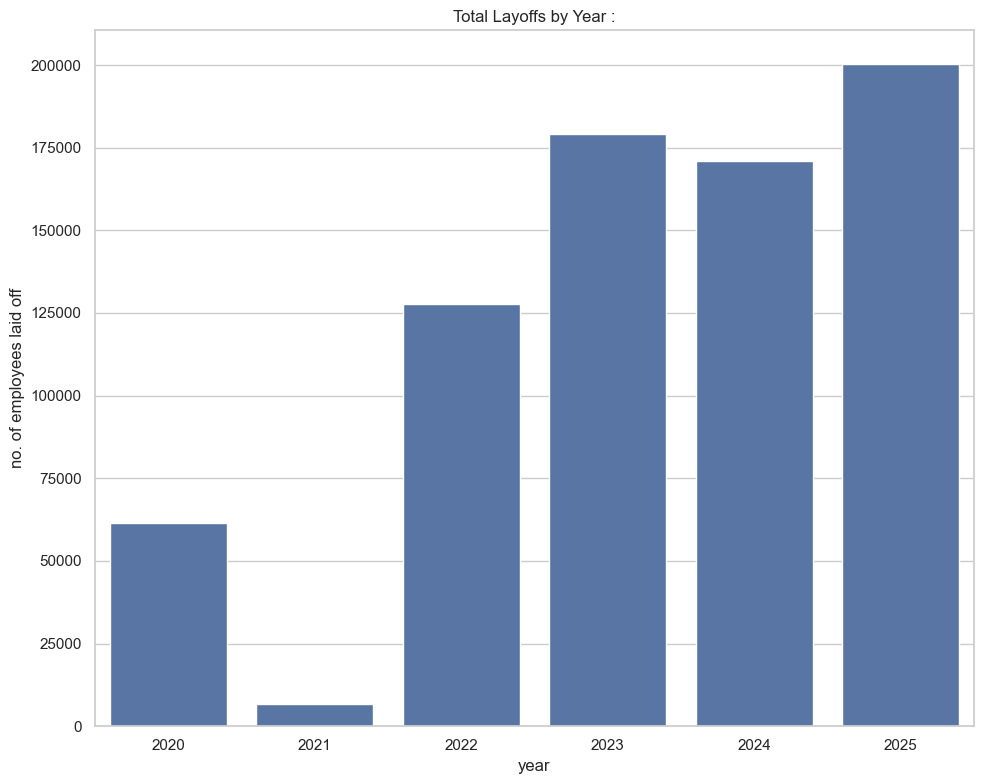

In [31]:
from IPython.display import display

Yearly_layoffs= (
    df.groupby("year")[layoff_col]
    .sum()
    .reset_index()
        .sort_values("year")
)

display(Yearly_layoffs)

plt.figure(figsize= (10,8))
sns.barplot(data= Yearly_layoffs, x="year", y=layoff_col)
plt.title("Total Layoffs by Year :")
plt.xlabel("year")
plt.ylabel("no. of employees laid off")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/layoffs_by_year.png")
plt.show()

,year_month,Laid_Off
0,2020-03,7441.0
1,2020-04,21864.0
2,2020-05,21404.0
3,2020-06,6092.0
4,2020-07,2198.0
...,...,...
61,2025-08,8956.0
62,2025-09,21340.0
63,2025-10,34124.0
64,2025-11,40638.0


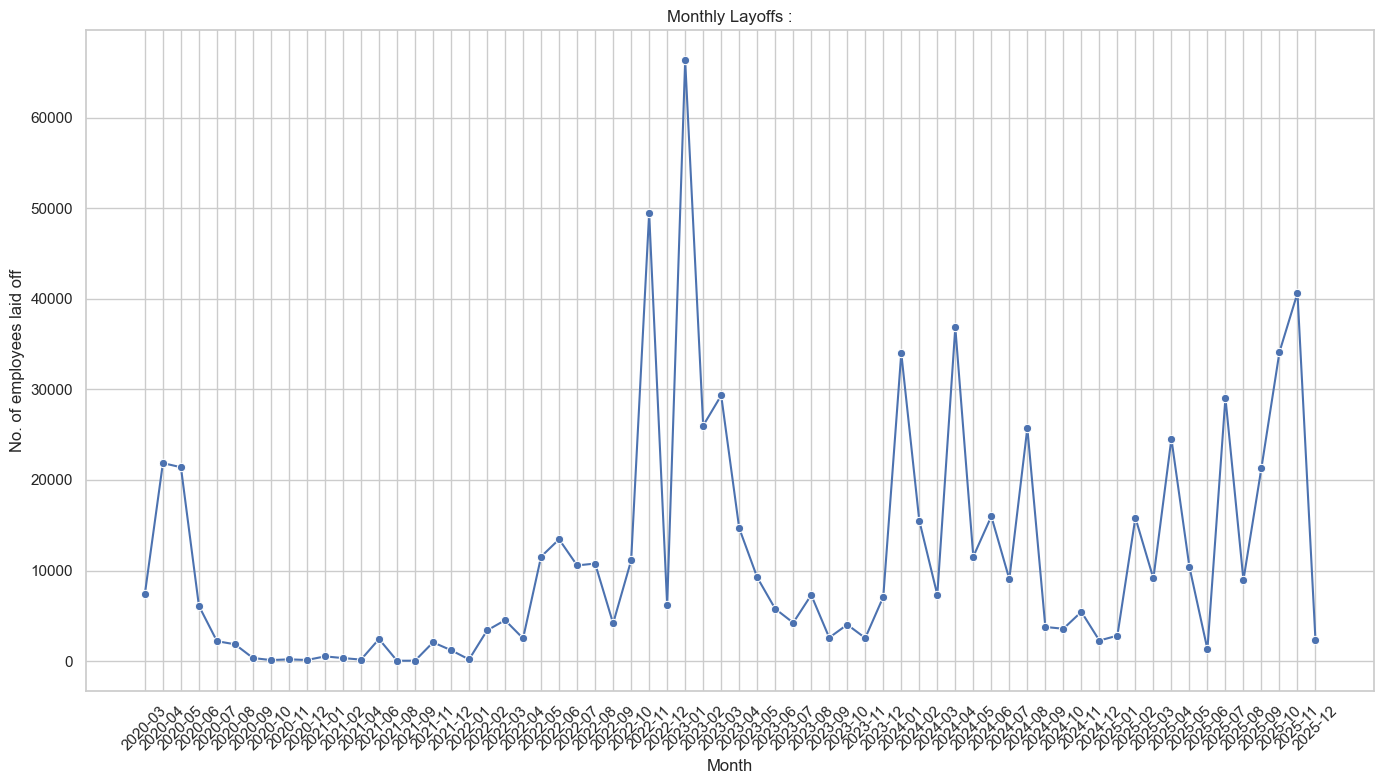

In [32]:
from IPython.display import display

monthly_layoffs=(
    df.groupby("year_month")[layoff_col]
    .sum()
    .reset_index()
    .sort_values("year_month")
)

display(monthly_layoffs)

plt.figure(figsize=(14,8))
sns.lineplot(data=monthly_layoffs, x="year_month", y=layoff_col, marker="o")
plt.title("Monthly Layoffs :")
plt.xlabel("Month")
plt.ylabel("No. of employees laid off")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/monthly_layoff.png")
plt.show()

,Company,Laid_Off
70,Amazon,72244.0
731,Intel,42953.0
930,Microsoft,31937.0
923,Meta,25350.0
1438,Tesla,20520.0
1583,Verizon,15000.0
612,Google,13982.0
302,Cisco,13950.0
1412,TCS,12365.0
1237,SAP,11000.0


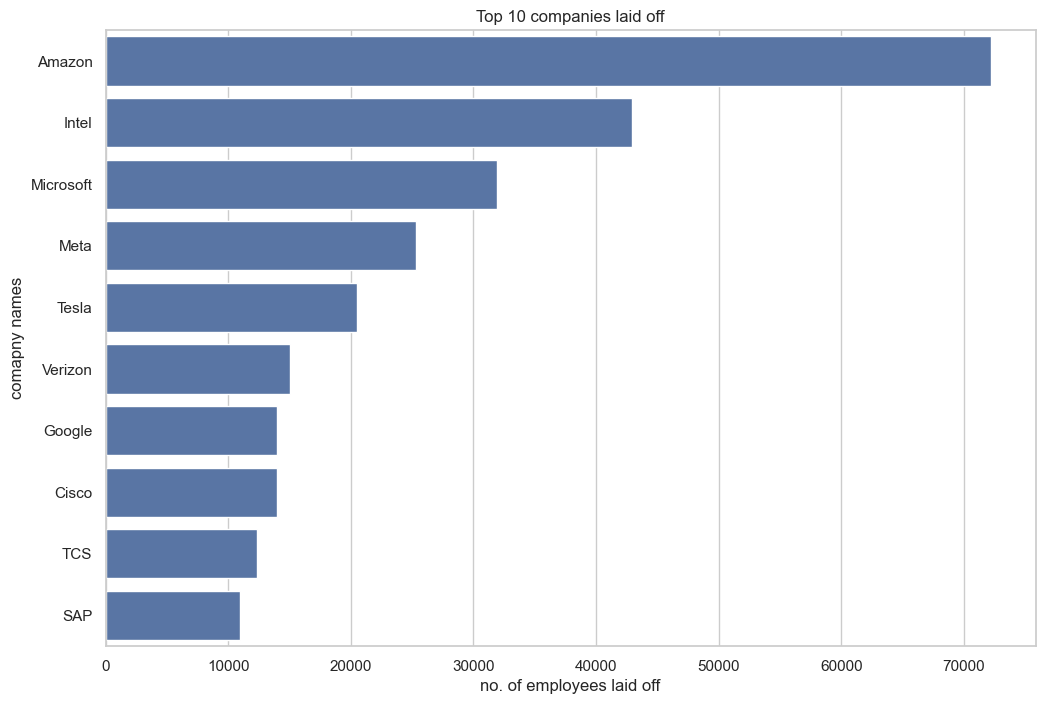

In [33]:
if company_col:
    top_companies=(
        df.groupby(company_col)[layoff_col]
        .sum()
        .reset_index()
        .sort_values(layoff_col, ascending=False)
        .head(10)
    )

display(top_companies)

plt.figure(figsize=(12,8))
sns.barplot(data=top_companies, x=layoff_col, y=company_col)
plt.title("Top 10 companies laid off")
plt.xlabel("no. of employees laid off")
plt.ylabel("comapny names")
plt.savefig(f"{CHART_DIR}/top_10_companies.png")
plt.show()

,Country,Laid_Off
45,USA,541854.0
17,India,55212.0
15,Germany,28933.0
41,Sweden,17201.0
44,UK,17078.0
5,Canada,14195.0
20,Israel,14000.0
19,Ireland,12191.0
21,Japan,9298.0
4,Brazil,7029.0


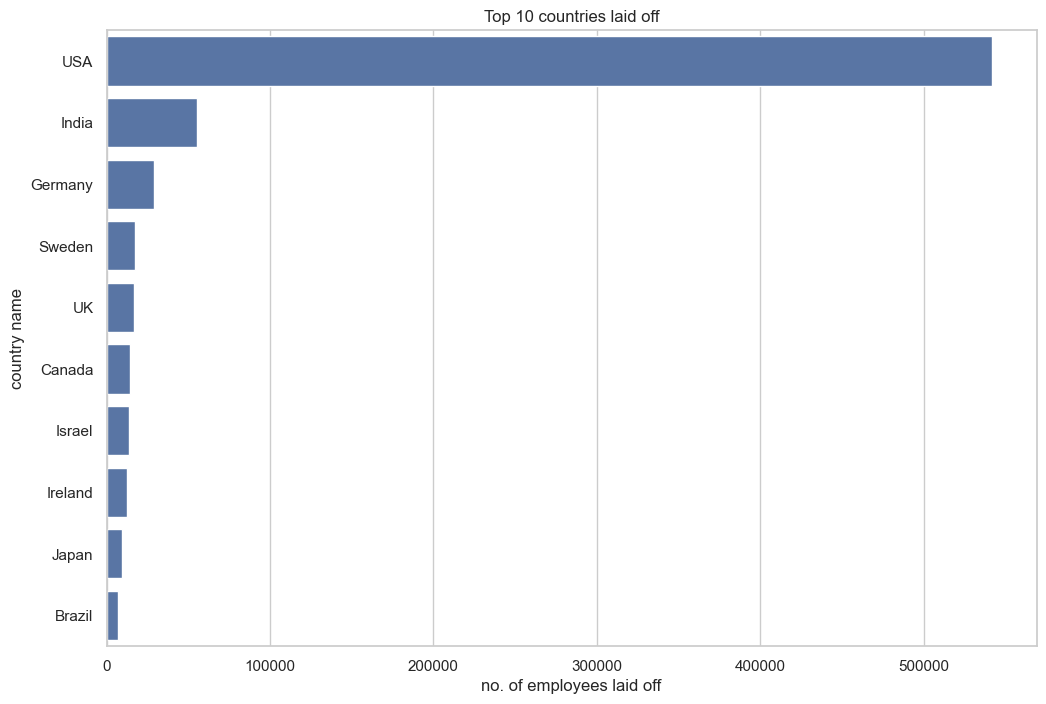

In [34]:
if country_col:
    top_countries=(
        df.groupby(country_col)[layoff_col]
        .sum()
        .reset_index()
        .sort_values(layoff_col, ascending=False)
        .head(10)
    )

display(top_countries)

plt.figure(figsize=(12,8))
sns.barplot(data=top_countries, x=layoff_col, y=country_col)
plt.title("Top 10 countries laid off")
plt.xlabel("no. of employees laid off")
plt.ylabel("country name")
plt.savefig(f"{CHART_DIR}/top_10_countries.png")
plt.show()

,Industry,Laid_Off
26,Consumer,65642.0
87,Retail,62190.0
57,Hardware,60842.0
81,Other,57891.0
97,Software Development,43634.0
106,Transportation,42980.0
46,Finance,42857.0
50,Food,39006.0
35,E-commerce,30874.0
63,IT Services and IT Consulting,22066.0


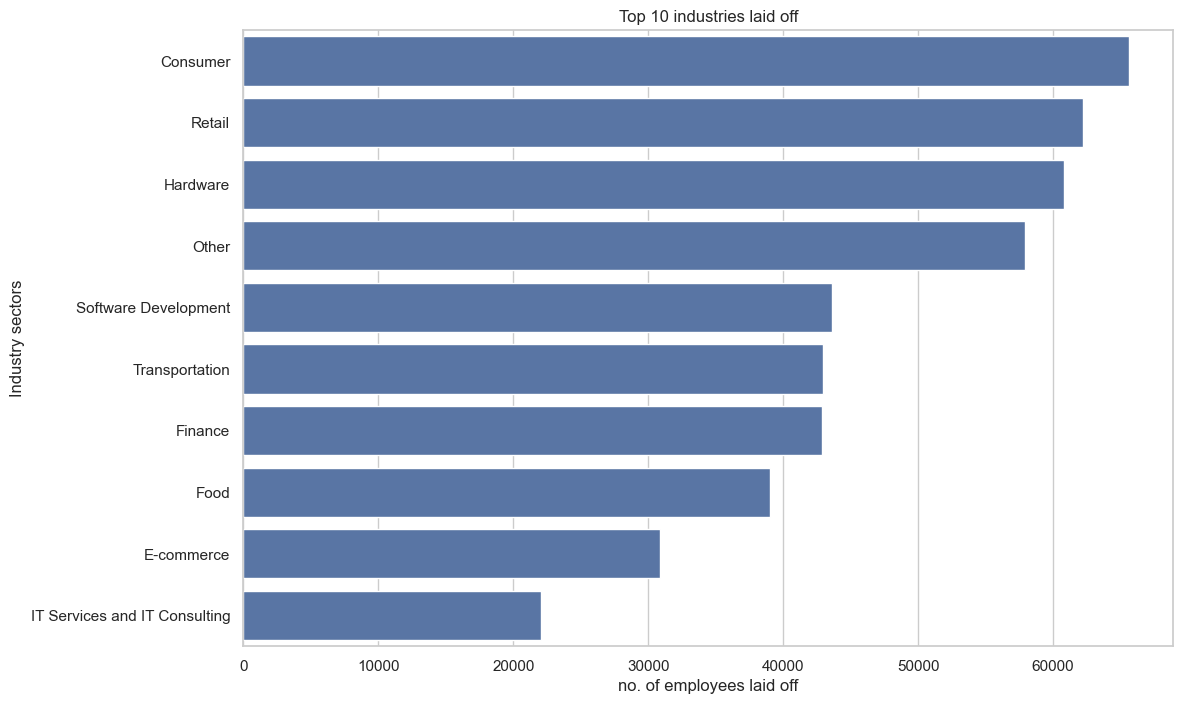

In [35]:
if industry_col: 
    top_industries=(
        df.groupby(industry_col)[layoff_col]
        .sum()
        .reset_index()
        .sort_values(layoff_col, ascending= False)
        .head(10)
 )

display(top_industries)

plt.figure(figsize=(12,8))
sns.barplot(data=top_industries, x=layoff_col, y=industry_col)
plt.title("Top 10 industries laid off")
plt.xlabel("no. of employees laid off")
plt.ylabel("Industry sectors")
plt.savefig(f"{CHART_DIR}/top_10_industries.png")
plt.show()

,Stage,Laid_Off
1,Post-IPO,375854.0
15,Unknown,79490.0
0,Acquired,35535.0
5,Series B,25036.0
7,Series D,22329.0
6,Series C,18491.0
8,Series E,17830.0
9,Series F,9877.0
2,Private Equity,8652.0
11,Series H,7413.0


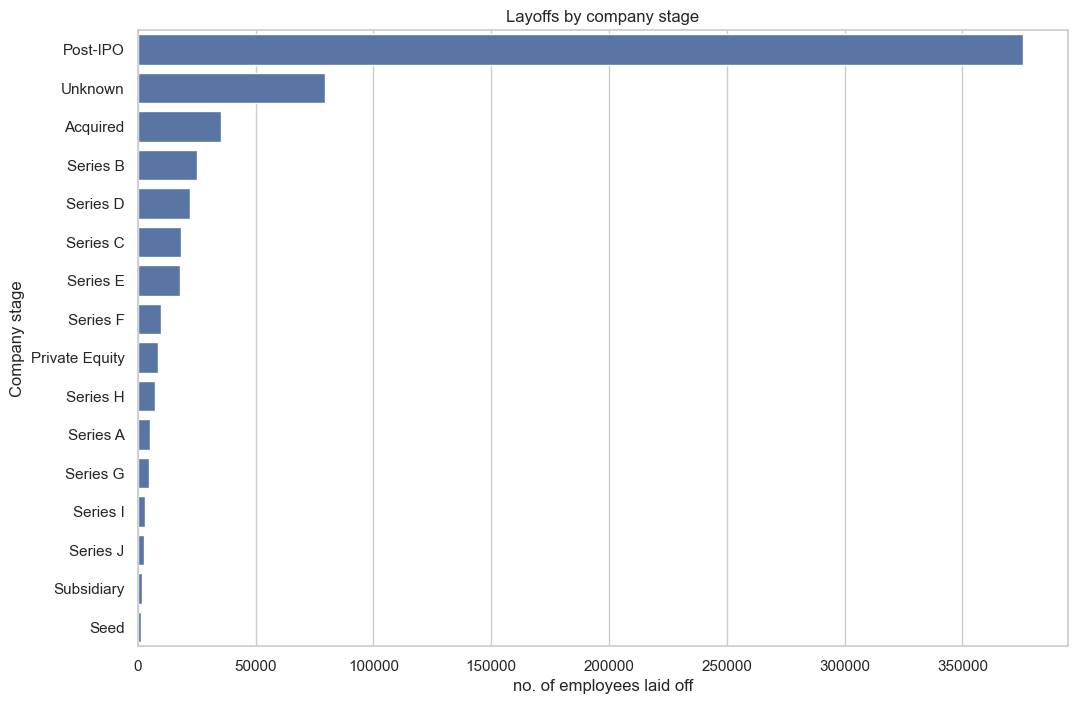

In [36]:
if stage_col:
    stage_layoffs=(
        df.groupby(stage_col)[layoff_col]
        .sum()
        .reset_index()
        .sort_values(layoff_col, ascending=False)
    )

display(stage_layoffs)

plt.figure(figsize=(12,8))
sns.barplot(data=stage_layoffs, x=layoff_col, y=stage_col)
plt.title("Layoffs by company stage")
plt.xlabel("no. of employees laid off")
plt.ylabel("Company stage")
plt.savefig(f"{CHART_DIR}/layoff_by_company_stage.png")
plt.show()

In [39]:
total_layoffs= int(df[layoff_col].sum())
print(f"Total layoffs recorded from 2020-25: {total_layoffs:,}")

peak_year= df.groupby("year")[layoff_col].sum().idxmax()
peak_year_layoffs= df.groupby("year")[layoff_col].sum().max()
print(f"The Year with highest layoffs: {peak_year} ({int(peak_year_layoffs):,} layoffs)")


Total layoffs recorded from 2020-25: 746,809
The Year with highest layoffs: 2025 (200,445 layoffs)
